In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
df= pd.read_csv('train.csv')

In [2]:
df.describe()
df["Age"]=df["Age"].fillna(df['Age'].mean())
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [3]:
df.describe()
df["Embarked"] = df["Embarked"].ffill()

In [4]:
df[(df["Sex"]=="female") & (df["Survived"]==1)].count()/(df["Sex"]=="female").count()
df[(df["Sex"]=="male") & (df["Survived"]==1)].count()/(df["Sex"]=="male").count()

PassengerId    0.122334
Survived       0.122334
Pclass         0.122334
Name           0.122334
Sex            0.122334
Age            0.122334
SibSp          0.122334
Parch          0.122334
Ticket         0.122334
Fare           0.122334
Cabin          0.050505
Embarked       0.122334
dtype: float64

In [5]:
female_death_ratio = df[(df["Sex"]=="female") & (df["Survived"]==1)].count()/(df["Sex"]=="female").count()
print(female_death_ratio["Name"])
male_death_ratio= df[(df["Sex"]=="male") & (df["Survived"]==1)].count()/(df["Sex"]=="male").count()
print(male_death_ratio["Name"])

0.2615039281705948
0.122334455667789


([<matplotlib.patches.Wedge at 0x176863346e0>,
 [Text(-0.8426490478933555, 0.7070661794234129, 's'),
  Text(0.6244729610611289, -0.9055570224472591, 'c'),
  Text(1.0604548348123313, -0.2922935909717338, 'q')])

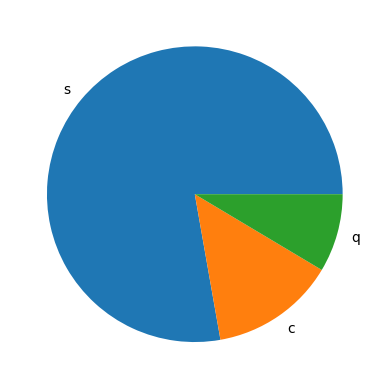

In [6]:
s = df[(df["Embarked"]=="S") & (df["Survived"]==0)].count()/(df["Embarked"]=="S").count()
c = df[(df["Embarked"]=="C") & (df["Survived"]==0)].count()/(df["Embarked"]=="C").count()
q = df[(df["Embarked"]=="Q") & (df["Survived"]==0)].count()/(df["Embarked"]=="Q").count()
plt.pie([s["Name"],c["Name"],q["Name"]],labels=["s","c","q"])

In [7]:
bins = [0, 20, 40, 60, 100]

# Put every passenger into an age group
df["AgeGroup"] = pd.cut(df["Age"], bins=bins)

# Total people in each age group
total = df.groupby("AgeGroup",observed=False).size()

# People who died in each age group
died = df[df["Survived"] == 0].groupby("AgeGroup",observed=False).size()

# Ratio
death_ratio = died / total

print(death_ratio)


AgeGroup
(0, 20]      0.541899
(20, 40]     0.635231
(40, 60]     0.609375
(60, 100]    0.772727
dtype: float64


Pclass
1    0.370370
2    0.527174
3    0.757637
dtype: float64


<BarContainer object of 3 artists>

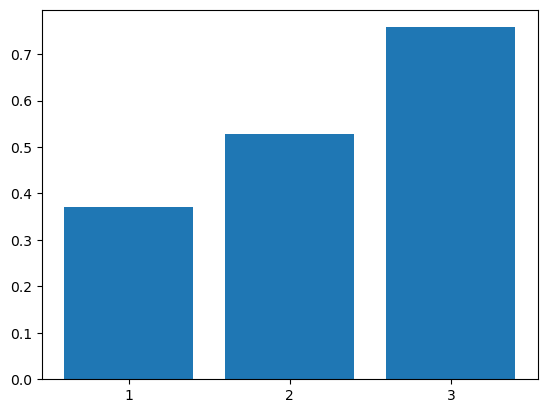

In [8]:


total = df.groupby("Pclass",observed=False).size()

died = df[df["Survived"] == 0].groupby("Pclass",observed=False).size()

death_ratio = died / total
print(death_ratio)
plt.bar(["1","2","3"],death_ratio)

SibSp
0    0.654605
1    0.464115
2    0.535714
3    0.750000
4    0.833333
5    1.000000
8    1.000000
dtype: float64


<BarContainer object of 7 artists>

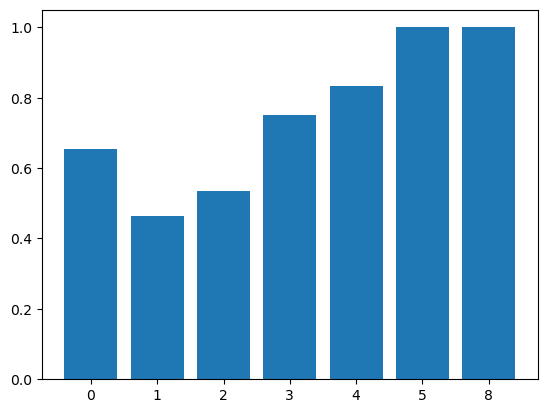

In [9]:
total = df.groupby("SibSp",observed=False).size()

died = df[df["Survived"] == 0].groupby("SibSp",observed=False).size()

death_ratio = died / total
print(death_ratio)
plt.bar(["0","1","2","3","4","5","8"],death_ratio)

Parch
0    0.656342
1    0.449153
2    0.500000
3    0.400000
4    1.000000
5    0.800000
6    1.000000
dtype: float64


<BarContainer object of 7 artists>

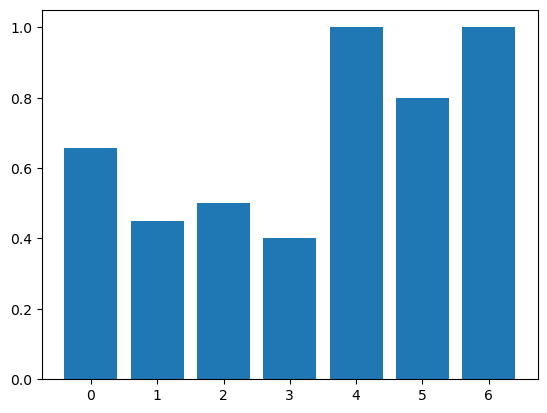

In [10]:
total = df.groupby("Parch",observed=False).size()

died = df[df["Survived"] == 0].groupby("Parch",observed=False).size()

death_ratio = died / total
print(death_ratio)
plt.bar(["0","1","2","3","4","5","6"],death_ratio)

In [11]:
# df= df.drop(columns=["Ticket"])
# df=df.drop(columns=["SS"])
df.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked', 'AgeGroup'],
      dtype='object')

<Axes: xlabel='Pclass', ylabel='Fare'>

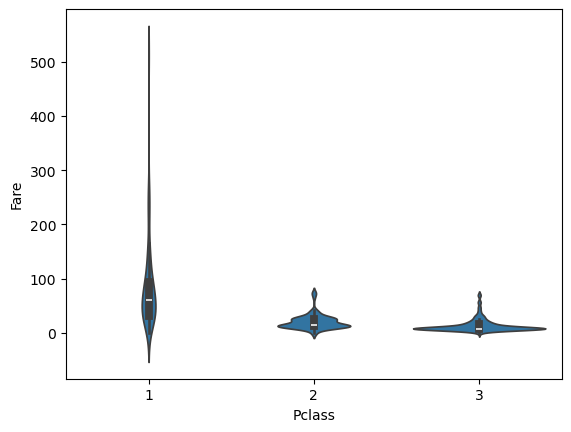

In [12]:
import seaborn as sns
data = df[["Fare","Pclass"]]
sns.violinplot(x="Pclass",y="Fare",data = df)

<Axes: xlabel='Pclass', ylabel='Age'>

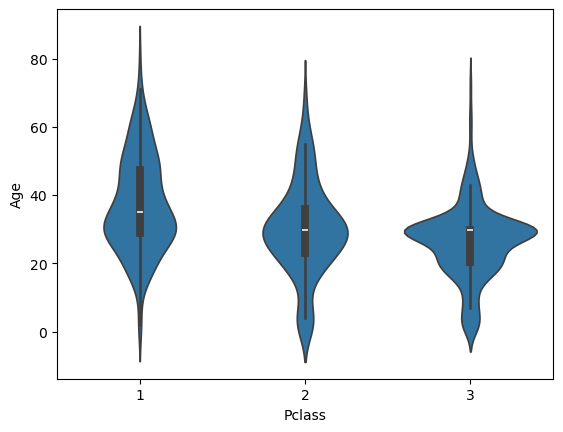

In [13]:
import seaborn as sns
data = df[["Age","Pclass"]]
sns.violinplot(x="Pclass",y="Age",data = df)

<Axes: xlabel='Embarked', ylabel='Pclass'>

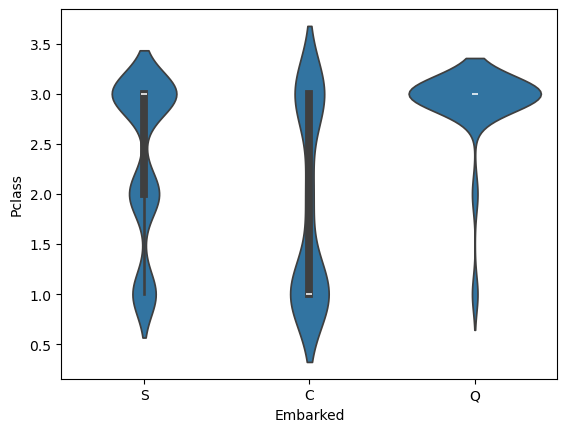

In [14]:
import seaborn as sns
data = df[["Pclass","Embarked"]]
sns.violinplot(y="Pclass",x="Embarked",data = df)

<Axes: xlabel='Pclass', ylabel='Age'>

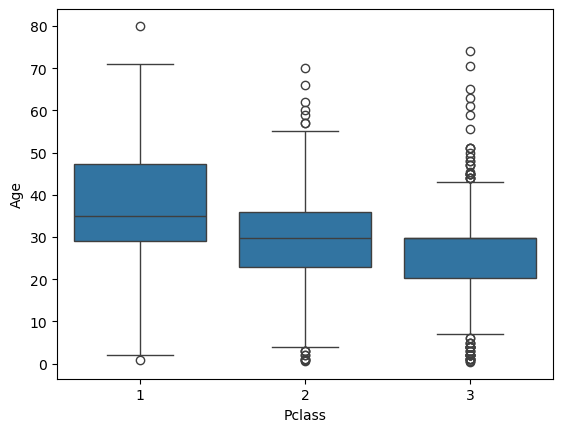

In [15]:
import seaborn as sns
data = df[["Age","Pclass"]]
sns.boxplot(x="Pclass",y="Age",data = df)

In [16]:
df=df.drop(columns=['Cabin'])


<Axes: xlabel='Sex', ylabel='Parch'>

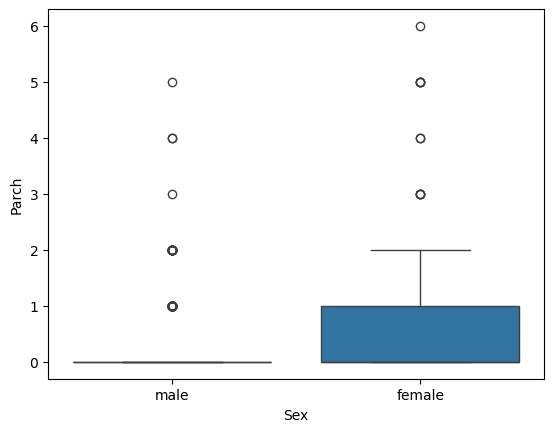

In [17]:
import seaborn as sns
data = df[["Parch","Sex"]]
sns.boxplot(x="Sex",y="Parch",data=data)

<Axes: xlabel='Sex', ylabel='SibSp'>

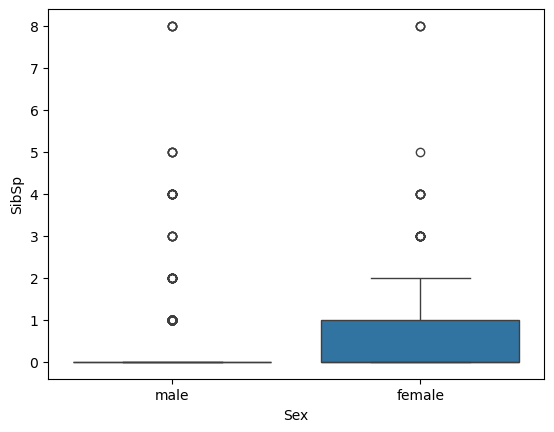

In [18]:
import seaborn as sns
data = df[["SibSp","Sex"]]
sns.boxplot(x="Sex",y="SibSp",data=data)

<Axes: xlabel='Pclass', ylabel='SibSp'>

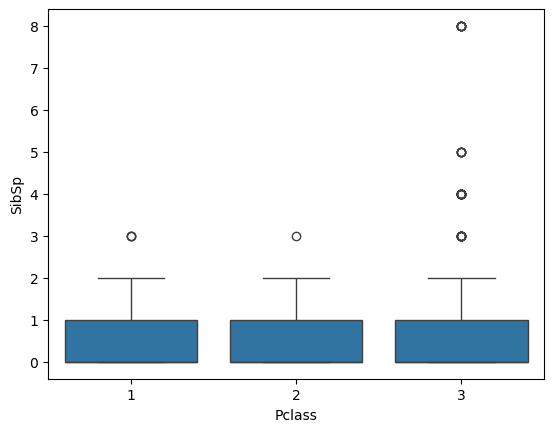

In [19]:
import seaborn as sns
data = df[["SibSp","Pclass"]]
sns.boxplot(x="Pclass",y="SibSp",data=data)

<Axes: xlabel='Pclass', ylabel='Parch'>

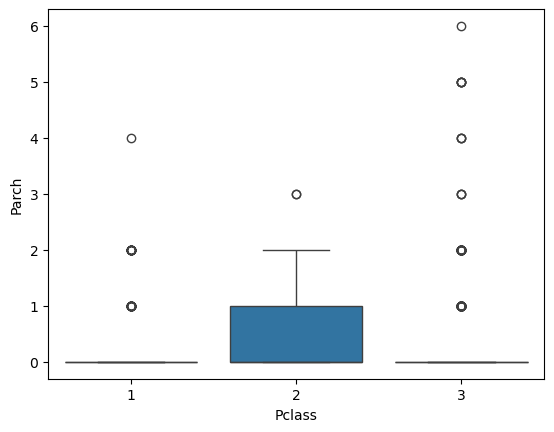

In [20]:
import seaborn as sns
data = df[["Parch","Pclass"]]
sns.boxplot(x="Pclass",y="Parch",data=data)

In [26]:
import numpy as np
cat_column = df[["Embarked"]]
from sklearn.preprocessing import OneHotEncoder
cat_encoder = OneHotEncoder(sparse_output=False)
embarked_encoded = cat_encoder.fit_transform(cat_column)
encoded_df = pd.DataFrame(embarked_encoded,columns=cat_encoder.get_feature_names_out(["Embarked"]))
df = pd.concat([df,encoded_df],axis=1)

In [27]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208,0.352413,0.647587,0.189675,0.087542,0.722783
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429,0.477990,0.477990,0.392264,0.282787,0.447876
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400,0.000000,0.000000,0.000000,0.000000,0.000000
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200,0.000000,1.000000,0.000000,0.000000,1.000000
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000,1.000000,1.000000,0.000000,0.000000,1.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000,1.000000,1.000000,1.000000,1.000000


In [24]:
import numpy as np
cat_column = df[["Sex"]]
from sklearn.preprocessing import OneHotEncoder
cat_encoder = OneHotEncoder(sparse_output=False)
embarked_encoded = cat_encoder.fit_transform(cat_column)
encoded_df = pd.DataFrame(embarked_encoded,columns=cat_encoder.get_feature_names_out(["Sex"]))
df = pd.concat([df,encoded_df],axis=1)

In [44]:
X = df[["Sex_male","Sex_female","Embarked_C","Embarked_Q","Embarked_S","Age","Pclass","SibSp","Fare","Parch"]]
Y = df["Survived"]

In [51]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn import tree
model = LogisticRegression(random_state=42,max_iter=1000)
model2= RandomForestClassifier()
model3 = GradientBoostingClassifier(random_state=42)
clf = tree.DecisionTreeClassifier()
split = StratifiedShuffleSplit(n_splits=5,test_size=0.2,random_state=42)
for train_i,test_i in split.split(df,df["Survived"]):
    x_train = X.loc[train_i]
    x_test= X.loc[test_i]

    y_train = Y.loc[train_i]
    y_test =Y.loc[test_i]


# clf.fit(x_train,y_train)
model3.fit(x_train,y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [84]:

cat_column = tf[["Sex"]]
from sklearn.preprocessing import OneHotEncoder
cat_encoder = OneHotEncoder(sparse_output=False)
embarked_encoded = cat_encoder.fit_transform(cat_column)
encoded_tf = pd.DataFrame(embarked_encoded,columns=cat_encoder.get_feature_names_out(["Sex"]))
tf = pd.concat([tf,encoded_tf],axis=1)

cat_column = tf[["Embarked"]]
from sklearn.preprocessing import OneHotEncoder
cat_encoder = OneHotEncoder(sparse_output=False)
embarked_encoded = cat_encoder.fit_transform(cat_column)
encoded_tf = pd.DataFrame(embarked_encoded,columns=cat_encoder.get_feature_names_out(["Embarked"]))
tf = pd.concat([tf,encoded_tf],axis=1)

tf.drop(columns=["Cabin","Ticket"])


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S
0,892,3,"Kelly, Mr. James",male,34.500000,0,0,7.8292,Q,0.0,1.0,0.0,1.0,0.0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.000000,1,0,7.0000,S,1.0,0.0,0.0,0.0,1.0
2,894,2,"Myles, Mr. Thomas Francis",male,62.000000,0,0,9.6875,Q,0.0,1.0,0.0,1.0,0.0
3,895,3,"Wirz, Mr. Albert",male,27.000000,0,0,8.6625,S,0.0,1.0,0.0,0.0,1.0
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.000000,1,1,12.2875,S,1.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,29.699118,0,0,8.0500,S,0.0,1.0,0.0,0.0,1.0
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.000000,0,0,108.9000,C,1.0,0.0,1.0,0.0,0.0
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.500000,0,0,7.2500,S,0.0,1.0,0.0,0.0,1.0
416,1308,3,"Ware, Mr. Frederick",male,29.699118,0,0,8.0500,S,0.0,1.0,0.0,0.0,1.0


In [83]:
import numpy as np
import pandas as pd
tf = pd.read_csv("test.csv")
tf["Age"]=tf["Age"].fillna(df["Age"].mean())
tf["Embarked"]=tf["Embarked"].ffill()
tf["Fare"] =tf["Fare"].fillna(df["Fare"].mean())

In [85]:
tf["Fare"].isnull().sum()

np.int64(0)

In [86]:
from sklearn.metrics import accuracy_score


X_test = tf[["Sex_male","Sex_female","Embarked_C","Embarked_Q","Embarked_S","Age","Pclass","SibSp","Fare","Parch"]]

y_pred = model3.predict(X_test)

tf["Survived"]=y_pred

In [90]:
tf = tf[["PassengerId","Survived"]]
tf.to_csv("Submissions.csv",index=False)